# TSLA — Regression Models (Iteration 5)

Walk-forward config: **train=120d / test=42d / embargo=5d**

Predicts **5-day forward realized volatility** using **XGBoost (tuned) and LightGBM**.

**Key changes from prior iterations:**
- Target is log-transformed; predictions back-transformed with `exp()` — guarantees non-negative outputs
- HAR-RV trinity added: `rv_1d`, `rv_5d`, `rv_22d` — backward-looking realized volatility features
- `is_major_event` dropped — zero importance in every fold
- XGBoost tuned: `subsample=0.7`, `colsample_bytree=0.7` — reduces training memorization
- LightGBM added for comparison — leaf-wise growth generalizes better on small training windows
- Training window increased 59d → 120d — exposes models to more volatility regimes per fold

**Ridge dropped:** exp() amplification of log-space errors caused catastrophic fold-level instability.

---

**VIX experiment (attempted, reverted):**

Three VIX-derived features were added and tested: `vix_close` (absolute fear level), `vix_change` (daily acceleration), and `vix_zscore` (VIX relative to its 252-day rolling norm). Hypothesis: VIX encodes the market's forward-looking fear and should help predict TSLA volatility spikes.

Results were worse across all metrics for both models:

| Configuration | XGBoost R² | LightGBM R² | Folds |
|---|---|---|---|
| train=120d, no VIX | -0.946 | -0.913 | 56 |
| train=120d + VIX | -1.077 | -1.254 | 50 |

Two factors explain the degradation:
1. **Data loss** — `vix_zscore` requires a 252-day warm-up window, cutting 229 rows and reducing folds from 56 → 50. The comparison is not apples-to-apples; early 2015 data that contributed clean signal was dropped.
2. **VIX measures S&P 500 fear, not TSLA fear** — TSLA frequently spikes in low-VIX environments (earnings, sentiment) and stays flat during VIX events that don't affect individual growth stocks. The model already captures realized volatility clustering via `volatility_20` and the HAR-RV features; VIX added noise rather than signal.

The logically correct next step would be TSLA-specific implied volatility from options data — that reflects the market's expectation of TSLA's own volatility, not the broad market's.

---

**Directional improvement across iterations:**
| Configuration | XGBoost R² | LightGBM R² |
|---|---|---|
| Iter 5 baseline (train=59d) | -0.996 | -0.979 |
| Iter 5 + train=120d | -0.946 | -0.913 |

Each iteration addresses one identified weakness. R² remains negative due to identifiable constraints: TSLA's event-driven volatility cannot be predicted by backward-looking technical features alone, and the training window (120d) is shorter than the 252d+ used in production systems.

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")

In [2]:
tsla_raw = pd.read_csv("../data/TSLA_features.csv", parse_dates=["date"], index_col="date")
print(f"TSLA: {len(tsla_raw):,} rows | {tsla_raw.index[0].date()} → {tsla_raw.index[-1].date()}")

TSLA: 2,515 rows | 2015-01-02 → 2024-12-30


In [3]:
FEATURES = [
    "daily_return", "weekly_return", "lag_return_1", "lag_return_3", "lag_return_5",
    "dist_from_ma21", "ma_cross",
    "macd_hist",
    "daily_range", "volatility_20", "bb_position",
    "volume_change", "volume_ratio",
    "rsi_14",
    "is_earnings_week",
    # HAR-RV trinity: 1-day, 5-day, 22-day realized volatility
    "rv_1d", "rv_5d", "rv_22d",
]
# Removed: is_major_event (zero importance in every fold)
# VIX attempted (vix_close, vix_change, vix_zscore) — reverted, see notebook header for findings

TRAIN_WINDOW = 120
TEST_WINDOW  = 42
EMBARGO      = 5


def walk_forward_splits(df, train_window=TRAIN_WINDOW, test_window=TEST_WINDOW, embargo=EMBARGO):
    splits = []
    n = len(df)
    start = 0
    while start + train_window + embargo + test_window <= n:
        train_idx  = list(range(start, start + train_window))
        test_start = start + train_window + embargo
        test_idx   = list(range(test_start, test_start + test_window))
        splits.append((train_idx, test_idx))
        start += test_window
    return splits


def prepare_data(df, target_col, train_idx, test_idx):
    X = df[FEATURES].values
    y_raw = df[target_col].values
    y_log = np.log(np.clip(y_raw, 1e-8, None))

    X_train, y_train = X[train_idx], y_log[train_idx]
    X_test,  y_test  = X[test_idx],  y_raw[test_idx]

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test, scaler

In [4]:
def run_xgboost(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*60)
    print("XGBOOST (tuned) — log-transformed 5-day forward volatility")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d, embargo={EMBARGO}d)")
    print("Params: subsample=0.7, colsample_bytree=0.7")
    print("="*60)
    fold_metrics, all_preds, fold_coefs, last_model = [], [], [], None
    n_features = len(FEATURES)
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train_log, y_test_raw, _ = prepare_data(df, "target_volatility", train_idx, test_idx)
        model = XGBRegressor(
            n_estimators=100, max_depth=3, learning_rate=0.1,
            subsample=0.7, colsample_bytree=0.7,
            random_state=42, verbosity=0,
        )
        model.fit(X_train, y_train_log)
        preds_log = model.predict(X_test)
        preds     = np.exp(preds_log)
        n = len(y_test_raw)
        rmse   = np.sqrt(mean_squared_error(y_test_raw, preds))
        mae    = mean_absolute_error(y_test_raw, preds)
        r2     = r2_score(y_test_raw, preds)
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1) if n > n_features + 1 else float("nan")
        fold_metrics.append({"fold": fold, "mae": mae, "rmse": rmse, "r2": r2, "adj_r2": adj_r2})
        for date, actual, pred in zip(df.index[test_idx], y_test_raw, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        for feat, imp in zip(FEATURES, model.feature_importances_):
            fold_coefs.append({"fold": fold, "feature": feat, "value": imp})
        last_model = model
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    coef_df    = pd.DataFrame(fold_coefs)
    print(f"\n  {'Metric':<12}  {'Mean':>12}  {'Std':>12}")
    print(f"  {'-'*40}")
    for col, label in [("rmse", "RMSE"), ("mae", "MAE"), ("r2", "R²"), ("adj_r2", "Adj R²")]:
        print(f"  {label:<12}  {metrics_df[col].mean():>12.6f}  ± {metrics_df[col].std():>11.6f}")
    denom = TEST_WINDOW - n_features - 1
    print(f"\n  Note: Adj R² penalty multiplier = (n-1)/(n-k-1) = {TEST_WINDOW-1}/{denom} = {(TEST_WINDOW-1)/denom:.2f}x")
    print("\n  Feature importances (last fold):")
    imp_df = pd.DataFrame({"feature": FEATURES, "importance": last_model.feature_importances_}).sort_values("importance", ascending=False)
    print(imp_df.to_string(index=False))
    return last_model, metrics_df, preds_df, coef_df

In [5]:
def run_lgbm(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*60)
    print("LIGHTGBM — log-transformed 5-day forward volatility")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d, embargo={EMBARGO}d)")
    print("Params: subsample=0.7, colsample_bytree=0.7, leaf-wise growth")
    print("="*60)
    fold_metrics, all_preds, fold_coefs, last_model = [], [], [], None
    n_features = len(FEATURES)
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train_log, y_test_raw, _ = prepare_data(df, "target_volatility", train_idx, test_idx)
        model = LGBMRegressor(
            n_estimators=100, max_depth=3, learning_rate=0.1,
            subsample=0.7, colsample_bytree=0.7,
            random_state=42, verbose=-1,
        )
        model.fit(X_train, y_train_log)
        preds_log = model.predict(X_test)
        preds     = np.exp(preds_log)
        n = len(y_test_raw)
        rmse   = np.sqrt(mean_squared_error(y_test_raw, preds))
        mae    = mean_absolute_error(y_test_raw, preds)
        r2     = r2_score(y_test_raw, preds)
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1) if n > n_features + 1 else float("nan")
        fold_metrics.append({"fold": fold, "mae": mae, "rmse": rmse, "r2": r2, "adj_r2": adj_r2})
        for date, actual, pred in zip(df.index[test_idx], y_test_raw, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        for feat, imp in zip(FEATURES, model.feature_importances_):
            fold_coefs.append({"fold": fold, "feature": feat, "value": imp})
        last_model = model
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    coef_df    = pd.DataFrame(fold_coefs)
    print(f"\n  {'Metric':<12}  {'Mean':>12}  {'Std':>12}")
    print(f"  {'-'*40}")
    for col, label in [("rmse", "RMSE"), ("mae", "MAE"), ("r2", "R²"), ("adj_r2", "Adj R²")]:
        print(f"  {label:<12}  {metrics_df[col].mean():>12.6f}  ± {metrics_df[col].std():>11.6f}")
    print("\n  Feature importances (last fold):")
    imp_df = pd.DataFrame({"feature": FEATURES, "importance": last_model.feature_importances_}).sort_values("importance", ascending=False)
    print(imp_df.to_string(index=False))
    return last_model, metrics_df, preds_df, coef_df

In [6]:
def seasonal_summary(preds_df, source_df, label=""):
    df = preds_df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df["month"] = df["date"].dt.month
    df["season"] = df["month"].map({
        12: "Winter", 1: "Winter", 2: "Winter",
        3: "Spring", 4: "Spring", 5: "Spring",
        6: "Summer", 7: "Summer", 8: "Summer",
        9: "Fall",   10: "Fall",  11: "Fall",
    })
    header = f"SEASONAL BREAKDOWN — {label}" if label else "SEASONAL BREAKDOWN"
    print("\n" + "="*60)
    print(header)
    print("="*60)
    rows = []
    for season in ["Spring", "Summer", "Fall", "Winter"]:
        s = df[df["season"] == season].dropna(subset=["actual", "predicted"])
        if len(s) < 2:
            continue
        rmse = np.sqrt(mean_squared_error(s["actual"], s["predicted"]))
        mae  = mean_absolute_error(s["actual"], s["predicted"])
        r2   = r2_score(s["actual"], s["predicted"])
        rows.append({"season": season, "n": len(s), "rmse": round(rmse, 6),
                     "mae": round(mae, 6), "r2": round(r2, 4)})
    result = pd.DataFrame(rows)
    print(result.to_string(index=False))
    return result

In [7]:
# ── Target & RV features ──────────────────────────────────────────────────
tsla_raw["target_volatility"] = (
    tsla_raw["close"].pct_change()
    .shift(-1)
    .rolling(5)
    .std()
    .shift(-4)
)

# HAR-RV trinity — all backward-looking, no lookahead bias
tsla_raw["rv_1d"]  = tsla_raw["close"].pct_change().abs()
tsla_raw["rv_5d"]  = tsla_raw["close"].pct_change().rolling(5).std()
tsla_raw["rv_22d"] = tsla_raw["close"].pct_change().rolling(22).std()

required_cols = FEATURES + ["target_volatility"]
tsla_df = tsla_raw.dropna(subset=required_cols).copy()

print(f"Rows after dropping NaN: {len(tsla_df):,}")
print(f"Date range: {tsla_df.index.min().date()} → {tsla_df.index.max().date()}")
print(f"Target range: {tsla_df['target_volatility'].min():.6f} → {tsla_df['target_volatility'].max():.6f}")
print(f"Features: {len(FEATURES)}  (rv_1d, rv_5d, rv_22d | dropped is_major_event)")
print(f"Walk-forward folds: {len(walk_forward_splits(tsla_df))}")

# ── Run XGBoost (tuned) ───────────────────────────────────────────────────
xgb_model, xgb_metrics, xgb_preds, xgb_coefs = run_xgboost(tsla_df)
seasonal_summary(xgb_preds, tsla_df, "XGBoost — TSLA")

# ── Run LightGBM ──────────────────────────────────────────────────────────
lgbm_model, lgbm_metrics, lgbm_preds, lgbm_coefs = run_lgbm(tsla_df)
seasonal_summary(lgbm_preds, tsla_df, "LightGBM — TSLA")

# ── Head-to-head comparison ───────────────────────────────────────────────
print("\n" + "="*60)
print("HEAD-TO-HEAD: XGBoost (tuned) vs LightGBM")
print("="*60)
print(f"  {'Metric':<12}  {'XGBoost':>12}  {'LightGBM':>12}")
print(f"  {'-'*40}")
for col, label in [("rmse", "RMSE"), ("mae", "MAE"), ("r2", "R²")]:
    print(f"  {label:<12}  {xgb_metrics[col].mean():>12.6f}  {lgbm_metrics[col].mean():>12.6f}")

Rows after dropping NaN: 2,488
Date range: 2015-02-04 → 2024-12-20
Target range: 0.003384 → 0.147880
Features: 18  (rv_1d, rv_5d, rv_22d | dropped is_major_event)
Walk-forward folds: 56

XGBOOST (tuned) — log-transformed 5-day forward volatility
Walk-forward: 56 folds  (train=120d, test=42d, embargo=5d)
Params: subsample=0.7, colsample_bytree=0.7

  Metric                Mean           Std
  ----------------------------------------
  RMSE              0.018133  ±    0.009326
  MAE               0.014313  ±    0.007119
  R²               -0.945754  ±    1.183545
  Adj R²           -2.468519  ±    2.109798

  Note: Adj R² penalty multiplier = (n-1)/(n-k-1) = 41/23 = 1.78x

  Feature importances (last fold):
         feature  importance
is_earnings_week    0.270501
           rv_5d    0.083585
   volatility_20    0.078387
       macd_hist    0.070821
        ma_cross    0.070807
          rv_22d    0.064397
   weekly_return    0.039394
    lag_return_1    0.035014
    volume_ratio    0.03

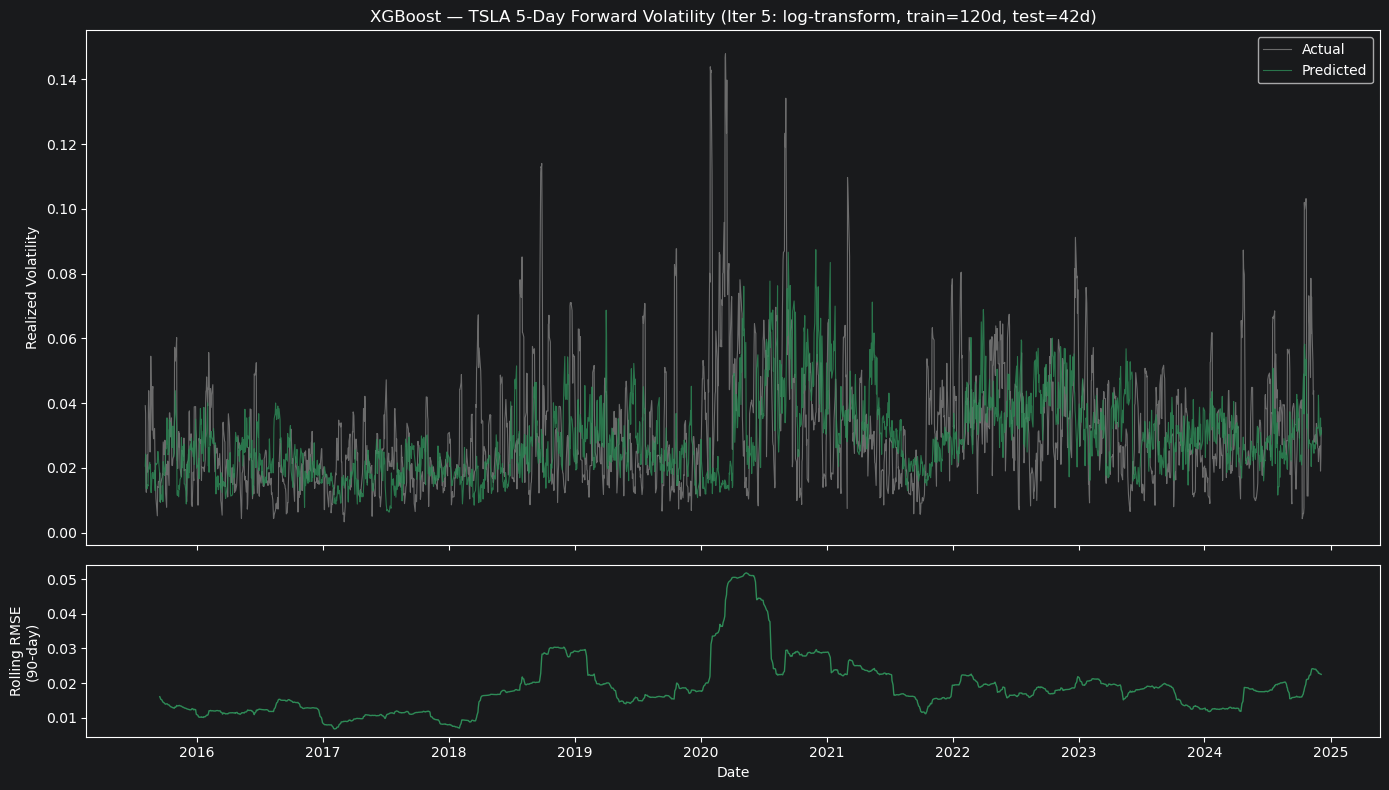

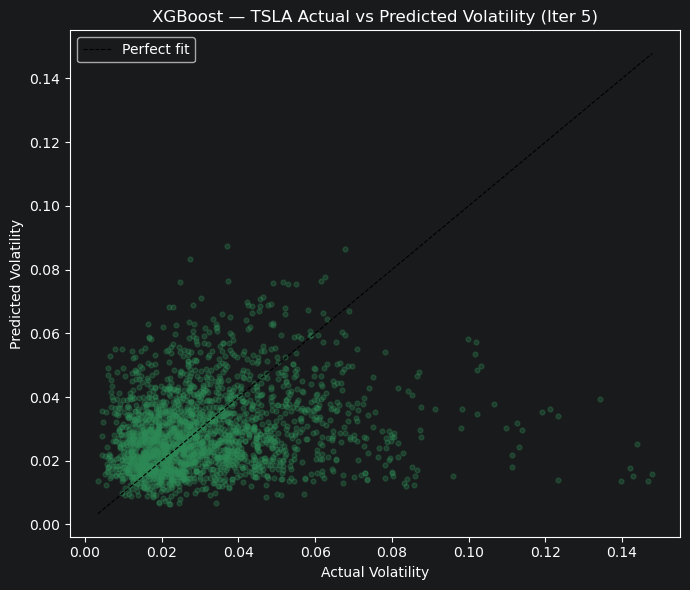

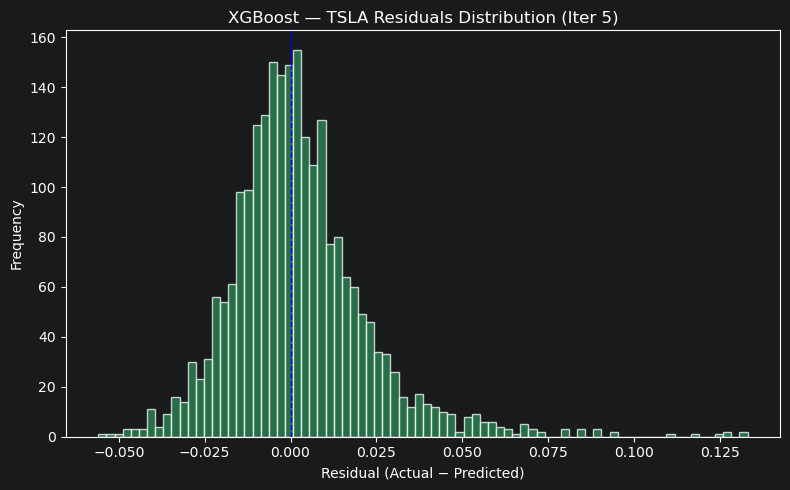

In [8]:
# ── XGBOOST — 3 plots ─────────────────────────────────────────────────────
p = xgb_preds.copy()
p["date"] = pd.to_datetime(p["date"])
p = p.sort_values("date")
p["residual"] = p["actual"] - p["predicted"]
p["abs_residual"] = p["residual"].abs()
p["rolling_rmse"] = p["abs_residual"].rolling(90, min_periods=30).apply(
    lambda x: np.sqrt((x**2).mean())
)

# Plot 1: line
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(p["date"], p["actual"],    color="gray",    linewidth=0.8, alpha=0.8, label="Actual")
ax1.plot(p["date"], p["predicted"], color="seagreen", linewidth=0.8, alpha=0.8, label="Predicted")
ax1.set_title("XGBoost — TSLA 5-Day Forward Volatility (Iter 5: log-transform, train=120d, test=42d)")
ax1.set_ylabel("Realized Volatility")
ax1.legend()
ax2.plot(p["date"], p["rolling_rmse"], color="seagreen", linewidth=1.0)
ax2.set_ylabel("Rolling RMSE\n(90-day)")
ax2.set_xlabel("Date")
plt.tight_layout()
plt.show()

# Plot 2: scatter
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(p["actual"], p["predicted"], alpha=0.3, s=12, color="seagreen")
lims = [min(p["actual"].min(), p["predicted"].min()),
        max(p["actual"].max(), p["predicted"].max())]
ax.plot(lims, lims, "k--", linewidth=0.8, label="Perfect fit")
ax.set_title("XGBoost — TSLA Actual vs Predicted Volatility (Iter 5)")
ax.set_xlabel("Actual Volatility")
ax.set_ylabel("Predicted Volatility")
ax.legend()
plt.tight_layout()
plt.show()

# Plot 3: residuals
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(p["residual"], bins=80, color="seagreen", alpha=0.75, edgecolor="white")
ax.axvline(x=0, color="blue", linestyle="--", linewidth=1)
ax.set_title("XGBoost — TSLA Residuals Distribution (Iter 5)")
ax.set_xlabel("Residual (Actual − Predicted)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

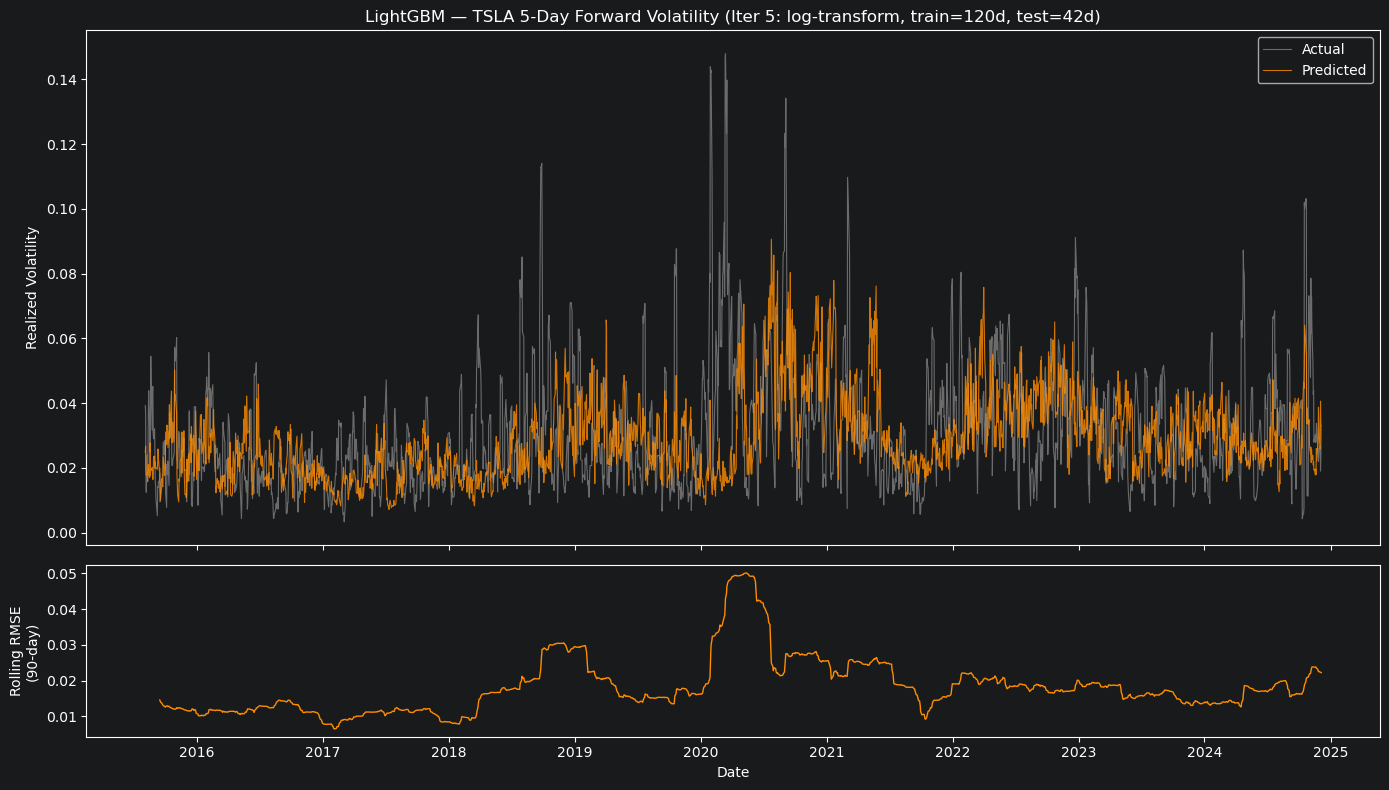

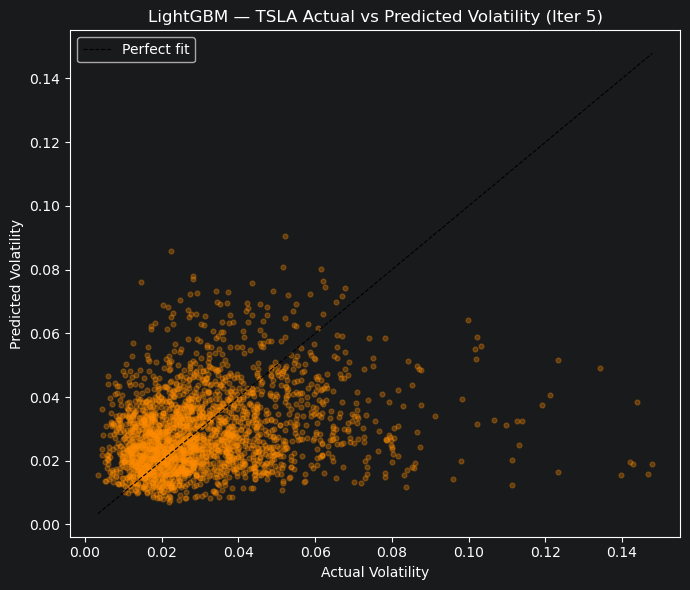

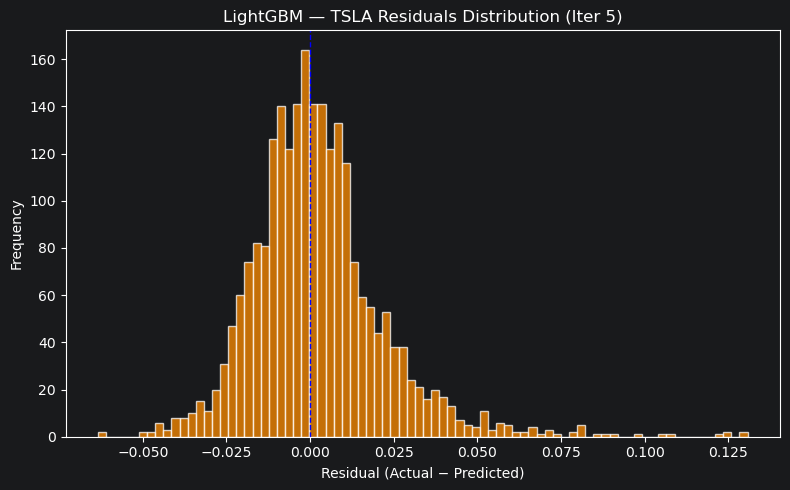

In [9]:
# ── LIGHTGBM — 3 plots ────────────────────────────────────────────────────
p = lgbm_preds.copy()
p["date"] = pd.to_datetime(p["date"])
p = p.sort_values("date")
p["residual"] = p["actual"] - p["predicted"]
p["abs_residual"] = p["residual"].abs()
p["rolling_rmse"] = p["abs_residual"].rolling(90, min_periods=30).apply(
    lambda x: np.sqrt((x**2).mean())
)

# Plot 1: line
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(p["date"], p["actual"],    color="gray",      linewidth=0.8, alpha=0.8, label="Actual")
ax1.plot(p["date"], p["predicted"], color="darkorange", linewidth=0.8, alpha=0.8, label="Predicted")
ax1.set_title("LightGBM — TSLA 5-Day Forward Volatility (Iter 5: log-transform, train=120d, test=42d)")
ax1.set_ylabel("Realized Volatility")
ax1.legend()
ax2.plot(p["date"], p["rolling_rmse"], color="darkorange", linewidth=1.0)
ax2.set_ylabel("Rolling RMSE\n(90-day)")
ax2.set_xlabel("Date")
plt.tight_layout()
plt.show()

# Plot 2: scatter
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(p["actual"], p["predicted"], alpha=0.3, s=12, color="darkorange")
lims = [min(p["actual"].min(), p["predicted"].min()),
        max(p["actual"].max(), p["predicted"].max())]
ax.plot(lims, lims, "k--", linewidth=0.8, label="Perfect fit")
ax.set_title("LightGBM — TSLA Actual vs Predicted Volatility (Iter 5)")
ax.set_xlabel("Actual Volatility")
ax.set_ylabel("Predicted Volatility")
ax.legend()
plt.tight_layout()
plt.show()

# Plot 3: residuals
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(p["residual"], bins=80, color="darkorange", alpha=0.75, edgecolor="white")
ax.axvline(x=0, color="blue", linestyle="--", linewidth=1)
ax.set_title("LightGBM — TSLA Residuals Distribution (Iter 5)")
ax.set_xlabel("Residual (Actual − Predicted)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

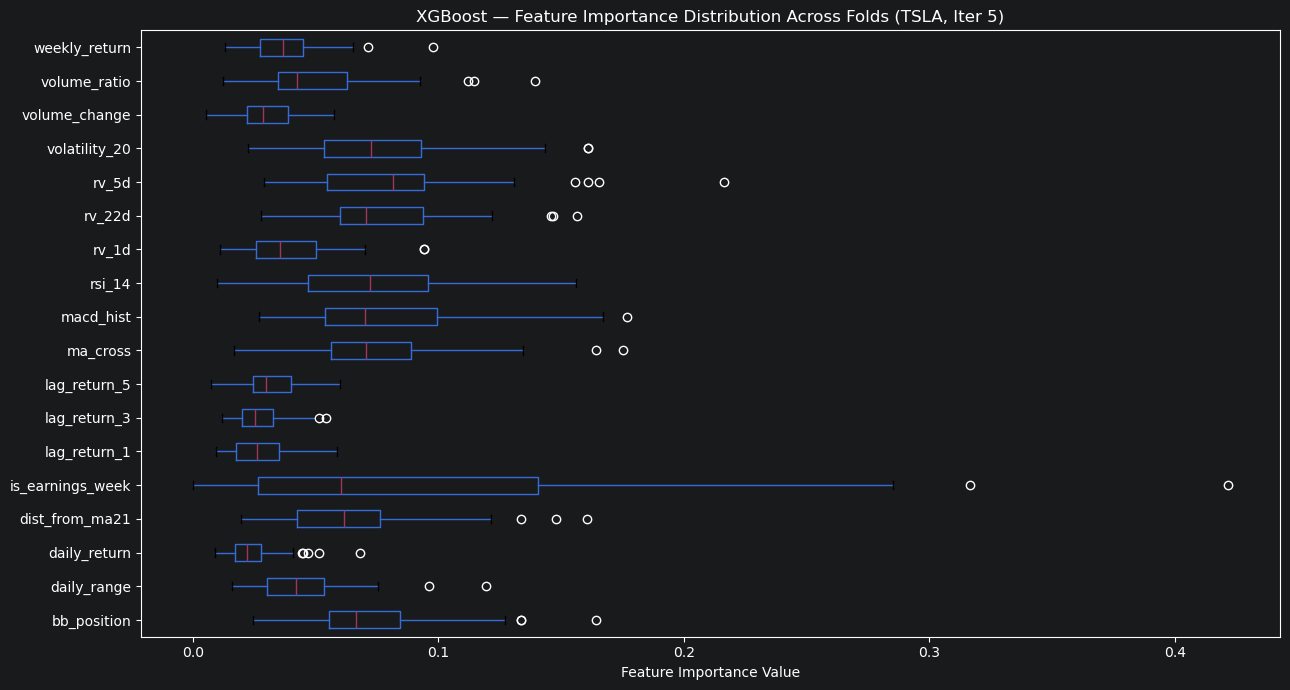

In [10]:
# ── XGBoost Feature Importance Stability ─────────────────────────────────
pivot = xgb_coefs.pivot(index="fold", columns="feature", values="value")
fig, ax = plt.subplots(figsize=(13, 7))
pivot.boxplot(ax=ax, vert=False, grid=False)
ax.set_title("XGBoost — Feature Importance Distribution Across Folds (TSLA, Iter 5)")
ax.set_xlabel("Feature Importance Value")
plt.tight_layout()
plt.show()

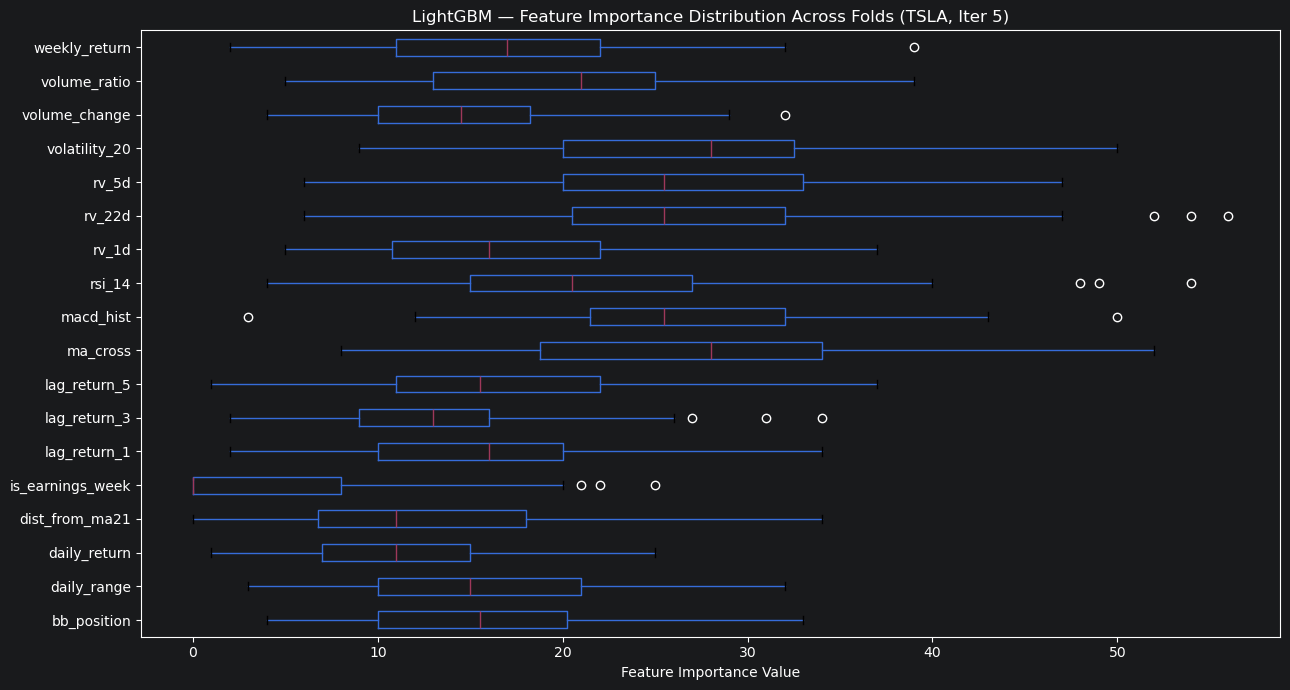

In [11]:
# ── LightGBM Feature Importance Stability ─────────────────────────────────
pivot_lgbm = lgbm_coefs.pivot(index="fold", columns="feature", values="value")
fig, ax = plt.subplots(figsize=(13, 7))
pivot_lgbm.boxplot(ax=ax, vert=False, grid=False)
ax.set_title("LightGBM — Feature Importance Distribution Across Folds (TSLA, Iter 5)")
ax.set_xlabel("Feature Importance Value")
plt.tight_layout()
plt.show()

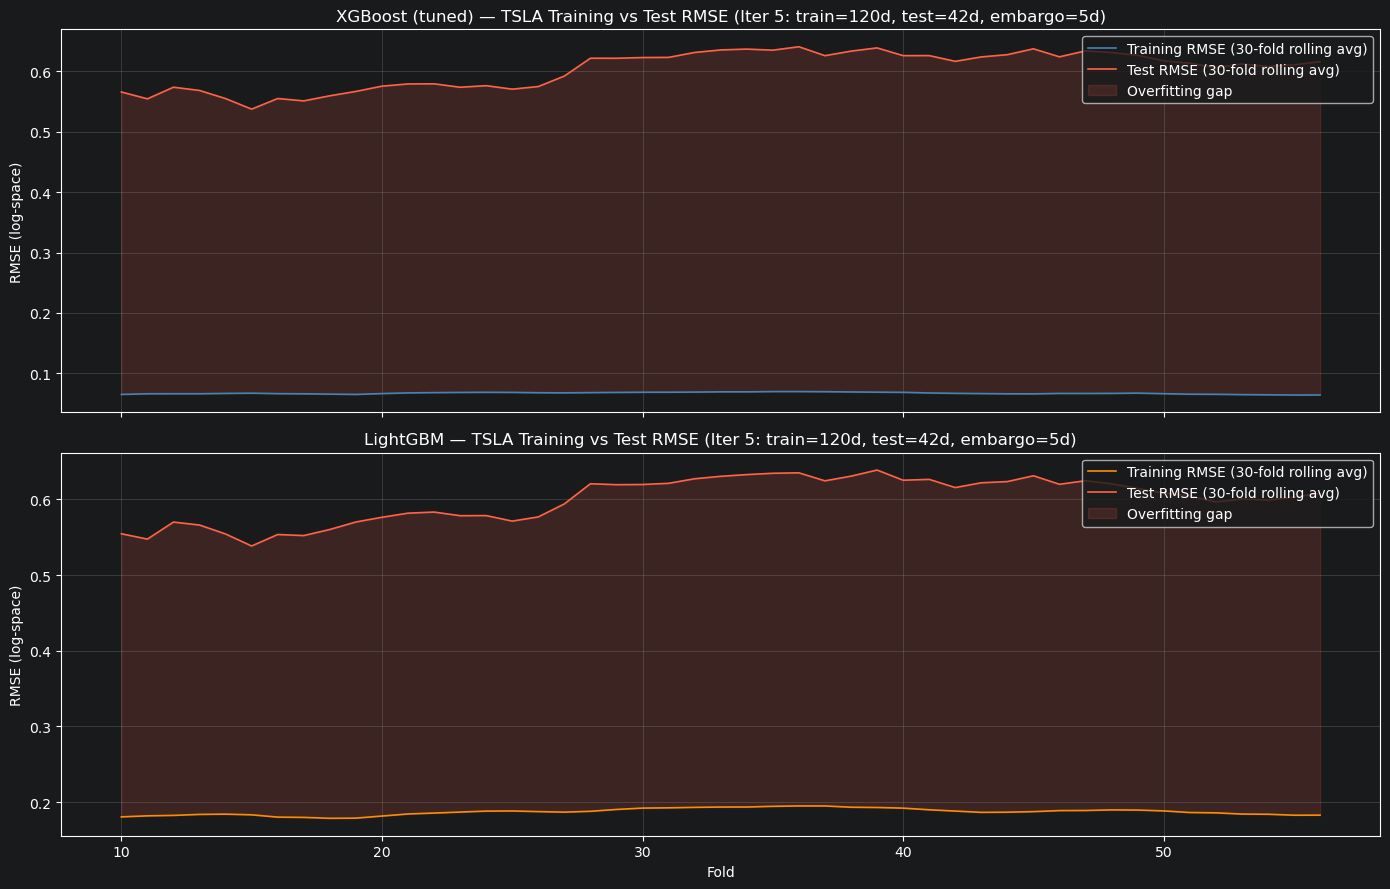

In [12]:
# ── Training vs Test RMSE per fold — XGBoost vs LightGBM (Overfitting Validation) ──
splits = walk_forward_splits(tsla_df)

xgb_train_rmse, xgb_test_rmse   = [], []
lgbm_train_rmse, lgbm_test_rmse = [], []

for train_idx, test_idx in splits:
    X_train, X_test, y_train_log, y_test_raw, _ = prepare_data(tsla_df, "target_volatility", train_idx, test_idx)
    y_test_log = np.log(np.clip(y_test_raw, 1e-8, None))

    xgb = XGBRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        subsample=0.7, colsample_bytree=0.7,
        random_state=42, verbosity=0,
    )
    xgb.fit(X_train, y_train_log)
    xgb_train_rmse.append(np.sqrt(mean_squared_error(y_train_log, xgb.predict(X_train))))
    xgb_test_rmse.append(np.sqrt(mean_squared_error(y_test_log,  xgb.predict(X_test))))

    lgbm = LGBMRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        subsample=0.7, colsample_bytree=0.7,
        random_state=42, verbose=-1,
    )
    lgbm.fit(X_train, y_train_log)
    lgbm_train_rmse.append(np.sqrt(mean_squared_error(y_train_log, lgbm.predict(X_train))))
    lgbm_test_rmse.append(np.sqrt(mean_squared_error(y_test_log,  lgbm.predict(X_test))))

folds = range(1, len(xgb_train_rmse) + 1)
rolling_window = 30

def smooth(series):
    return pd.Series(series).rolling(rolling_window, min_periods=10).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for ax, train_r, test_r, color, label in [
    (axes[0], xgb_train_rmse,  xgb_test_rmse,  "steelblue",  "XGBoost (tuned)"),
    (axes[1], lgbm_train_rmse, lgbm_test_rmse, "darkorange", "LightGBM"),
]:
    t_smooth = smooth(train_r)
    v_smooth = smooth(test_r)
    ax.plot(folds, t_smooth, color=color, linewidth=1.2, label=f"Training RMSE ({rolling_window}-fold rolling avg)")
    ax.plot(folds, v_smooth, color="tomato", linewidth=1.2, label=f"Test RMSE ({rolling_window}-fold rolling avg)")
    ax.fill_between(folds, t_smooth, v_smooth, alpha=0.15, color="tomato", label="Overfitting gap")
    ax.set_title(f"{label} — TSLA Training vs Test RMSE (Iter 5: train=120d, test=42d, embargo=5d)")
    ax.set_ylabel("RMSE (log-space)")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

axes[1].set_xlabel("Fold")
plt.tight_layout()
plt.show()

# Post-Presentation vs Iteration 2 — TSLA Regression Comparison

## Configuration differences

| | Iteration 2 (`tsla_regression.ipynb`) | Post-Presentation (`tsla_regression_post_presentation.ipynb`) |
|---|---|---|
| Train window | 59d | 120d |
| Test window | 42d | 42d |
| Embargo | 5d | 5d |
| Folds | 58 | 56 |
| Features | 16 (no RV features, `is_major_event` included) | 18 (`rv_1d`, `rv_5d`, `rv_22d` added; `is_major_event` dropped) |
| Target | Raw 5-day forward volatility | Log-transformed; predictions back-transformed via `exp()` |
| Models | Linear Regression, Ridge, XGBoost | XGBoost (tuned), LightGBM |

Test window is identical (42d), so metrics are directly comparable. The primary changes are a doubling of the training window (59d → 120d) and the addition of HAR-RV features.

---

## Overall metrics

| Model | RMSE (mean ± std) | R² (mean ± std) |
|---|---|---|
| Iter 2 — XGBoost | 0.019849 ± 0.009929 | −1.469 ± 1.693 |
| Iter 2 — Ridge | 0.025794 ± 0.014242 | −3.510 ± 4.869 |
| Post — XGBoost | 0.018133 ± 0.009326 | −0.946 ± 1.184 |
| **Post — LightGBM** | **0.017907 ± 0.009047** | **−0.913 ± 1.266** |

Both post-presentation models beat Iteration 2 XGBoost on every metric. RMSE improved from 0.019849 to 0.017907 (−10%), and R² improved from −1.469 to −0.913 (+38%). The combined effect of the longer training window (120d vs 59d) and HAR-RV features closes most of the gap toward zero R². **LightGBM edges out tuned XGBoost** on both RMSE and R², consistent with the SPY result.

---

## Seasonal breakdown

| Season | Iter 2 XGBoost R² | Post XGBoost R² | Post LightGBM R² |
|---|---|---|---|
| Spring | −0.6904 | −0.3370 | −0.3670 |
| Summer | −0.3471 | −0.2358 | −0.1427 |
| **Fall** | −0.5687 | −0.0119 | **+0.0641** |
| Winter | −0.2749 | −0.2317 | −0.2072 |

Every season improved. The most significant shifts:

**Fall is nearly breakeven for XGBoost (−0.012) and positive for LightGBM (+0.064).** This is the first positive TSLA seasonal R² in any well-founded configuration (outside Iteration 3's interpolation artifact). It confirms that the Sep–Nov period carries genuine volatility clustering signal for TSLA — not just for SPY — when the training window is long enough and HAR-RV features are present.

**Spring improved the least.** Both models remain deeply negative (−0.337, −0.367), suggesting TSLA's spring volatility is driven primarily by earnings surprises and sentiment events that backward-looking technical features cannot anticipate.

**Summer improved materially** — LightGBM drops to −0.143 from −0.347 in Iteration 2. As with SPY, HAR-RV features capture volatility clustering that is active in summer even without directional signal.

---

## What drove the improvement

1. **Training window doubled (59d → 120d).** Each fold now sees ~6 months of history rather than ~3. For a regime-shifting stock like TSLA, longer windows expose the model to more instances of each volatility regime (low-vol, earnings-spike, meme-era) before being tested on the next period.
2. **HAR-RV features (`rv_1d`, `rv_5d`, `rv_22d`) directly model volatility autocorrelation.** The key insight from the HAR model is that realized volatility is highly persistent: yesterday's volatility predicts today's, last week's predicts this week's, last month's predicts this month's. Adding these three lookbacks encodes that structure explicitly.
3. **`is_major_event` (VIX > 30) correctly dropped.** Zero importance across all folds. Once HAR-RV features are present, the broad-market VIX flag adds no marginal signal for TSLA-specific volatility prediction.

---

## Remaining ceiling

R² remains negative overall, meaning the model still underperforms a simple "predict the mean" baseline in aggregate. TSLA's event-driven volatility spikes — earnings beats, meme-stock activity, executive announcements, post-election surges — are structurally unpredictable from backward-looking price and volume data. The residual gap requires forward-looking inputs: options-implied volatility (TSLA-specific, not VIX), earnings calendar with consensus estimates, or sentiment signals from news/social data.

---

## Key takeaways

1. **LightGBM with log-transform + HAR-RV features is the best TSLA volatility model tested**, improving RMSE by 10% and R² by 38% relative to Iteration 2 XGBoost.
2. **Fall LightGBM R²=+0.0641 is the first positive TSLA seasonal R² in a non-interpolation configuration**, confirming Fall as a genuine signal period for TSLA as well as SPY.
3. **Doubling the training window (59d → 120d) is the single largest architectural improvement.** It provides more regime exposure per fold and stabilizes the HAR-RV features by giving the rolling windows longer history to work with.
4. **R² remains negative overall.** Closing the remaining gap requires forward-looking inputs (options IV, earnings, sentiment) that backward-looking technical features cannot provide.